# Rud Gallium MFA — Notebook 3

Material flow analysis (MFA) of gallium embodied in final LED products, based
on EUROSTAT COMEXT trade data: import/export tables, BAU and LED-adoption
projections, and a cohort-based dynamic stock-flow model.

In [14]:
##### Initial import and setup #####
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import plotly

# Ignore warnings for cleaner output
import warnings

warnings.filterwarnings("ignore", "Workbook contains no default style", UserWarning)

## ETL EUROSTAT data
### Extract: EUROSTAT COMEXT data

In [15]:
# Load data/EUROSTAT_COMEXT.csv into a DataFrame
comext_df = pd.read_csv("data/EUROSTAT_COMEXT.csv")

# Select relevant columns
selected_columns = [
    "reporter",
    "partner",
    "product",
    "PRODUCT",
    "flow",
    "FLOW",
    "indicators",
    "TIME_PERIOD",
    "OBS_VALUE",
]
eurostat_df = comext_df[selected_columns].copy()

### Transform: EUROSTAT COMEXT data

In [16]:
# TEMP: Filter out "product" starting with 87
eurostat_df = eurostat_df[~eurostat_df["product"].astype(str).str.startswith("87")]

# Display unique values for product and corresponding PRODUCT as dictionary
product_dict = dict(zip(eurostat_df["product"], eurostat_df["PRODUCT"]))
# print("Unique products and their corresponding PRODUCT codes:")
# for product, code in product_dict.items():
#     print(f"{product}: {code}")


# Categorymapping based on product codes.
# A category may map to a single product code or a list of codes (e.g. IC spans
# several CN codes); build_imp_exp_table handles both.
category_mapping = {
    # 'raw_Ga': 81129289,
    # 'intermediate_LED' : 854140,
    "intermediate_IC": [854231, 854232, 854233, 854239],
    "final_LED": 853950,
}


### Configure product info selection
Select which products are part of the analysis and setup their parameters (lifespan, market share, material intensity etc.)


Primary sources for material intensities, survival curve, lifespan, market share and product code for all products (in order of importance, high to low):
- (Gao et al., 2024)
- (Jia et al., 2022)
- (Løvik et al., 2015)

**Bibliography**:

Gao, Z., Geng, Y., Li, M., Liang, J.-J., & Houssini, K. (2024). Tracking the global anthropogenic gallium cycle during 2000–2020: A trade-linked multiregional material flow analysis. Global Environmental Change, 87, 102859. https://doi.org/10.1016/j.gloenvcha.2024.102859

Jia, H., Zhou, Y., Wang, A., Wang, G., Li, T., Wang, C., Xing, W., Ma, Z., & Li, P. (2022). Evolution of the Anthropogenic Gallium Cycle in China From 2005 to 2020. Frontiers in Energy Research, 10. https://doi.org/10.3389/fenrg.2022.944617

Løvik, A. N., Restrepo, E., & Müller, D. B. (2015). The Global Anthropogenic Gallium System: Determinants of Demand, Supply and Efficiency Improvements. Environmental Science & Technology, 49(9), 5704–5712. https://doi.org/10.1021/acs.est.5b00320


In [ ]:
# Create some data structure to hold categorical text, product code, lifespan, and material intensity.
# `product` may be a single code or a list of codes (e.g. intermediate_IC).
# NOTE: intermediate_IC currently reuses final_LED's parameters as dummy values.
# TODO Replace intermediate_IC dummy parameters with sourced values.
product_info = {
    "intermediate_IC": {
        "product": [854231, 854232, 854233, 854239],
        "lifespan_years": 2,  # Dummy: same as final_LED for now
        "market_share": 1,
        "material_intensity_Ga": 0.000014,
    },
    "final_LED": {
        "product": 853950,
        "lifespan_years": 6,  # Example lifespan for final LED products
        "market_share": 1,
        "material_intensity_Ga": 0.000014,
    },
}

# Raw (unwrought) gallium imported into the EU and manufactured domestically into
# finished products. It is NOT a use-phase product itself: it feeds Manufacturing
# (see the domestic-production stream, steps 2-5). Material intensity is ~1.0
# because unwrought gallium is essentially pure gallium, so translate_to_Ga_MI is
# effectively a no-op. The near-zero survival curve (fixed_lifetime of 1 year)
# encodes that raw gallium passes quickly through manufacturing.
raw_material_info = {
    "raw_Ga": {
        # "product": [811292],  # "Unwrought gallium; gallium powders"
        "product": [81129289],  # "Unwrought gallium; gallium powders"
        "material_intensity_Ga": 1.0,
        "survival_curve_parameters": {"type": "fixed_lifetime", "lifetime": 1},
    },
}

### Load: EUROSTAT COMEXT data
Based on product selection

In [18]:
def build_imp_exp_table(df, product_code, partner="EXT_EU27_2020"):
    """Build a yearly import/export/net-flow table (in kg) for a given product code.

    Filters and pivots dataframe.

    Args:
        df: COMEXT-format DataFrame containing at least the columns
            "product", "indicators", "partner", "FLOW", "TIME_PERIOD",
            and "OBS_VALUE".
        product_code: Product code (as used in the "product" column) to
            filter the data on. May be a single code or a list/tuple of
            codes (e.g. a category spanning several CN codes), in which case
            their flows are summed together.
        partner: Trade partner code to filter on. Defaults to
            "EXT_EU27_2020" (extra-EU27 trade).

    Returns:
        DataFrame: One row per TIME_PERIOD with columns "TIME_PERIOD",
        "Exports_kg", "Imports_kg", and "Net_Flow_kg" (Imports - Exports).
    """
    indicator = "QUANTITY_IN_100KG"
    scale_to_kg = 100
    # Normalize to a list so a single code and a list of codes are handled alike
    codes = product_code if isinstance(product_code, (list, tuple)) else [product_code]
    # Filter relevant records
    filtered_df = df[
        (df["product"].isin(codes))
        & (df["indicators"] == indicator)
        & (df["partner"] == partner)
    ].copy()

    # Convert unit (e.g., 100kg -> kg)
    filtered_df["OBS_VALUE_KG"] = filtered_df["OBS_VALUE"] * scale_to_kg

    # Aggregate by year and flow
    flow_df = filtered_df.groupby(["TIME_PERIOD", "FLOW"], as_index=False)[
        "OBS_VALUE_KG"
    ].sum()

    # Pivot to import/export columns
    pivot_df = flow_df.pivot(
        index="TIME_PERIOD", columns="FLOW", values="OBS_VALUE_KG"
    ).fillna(0)

    # Ensure both columns exist
    for col in ["EXPORT", "IMPORT"]:
        if col not in pivot_df.columns:
            pivot_df[col] = 0

    pivot_df = pivot_df.rename(columns={"EXPORT": "Exports_kg", "IMPORT": "Imports_kg"})
    pivot_df["Net_Flow_kg"] = pivot_df["Imports_kg"] - pivot_df["Exports_kg"]
    pivot_df = pivot_df.reset_index()

    # return filtered_df, flow_df, pivot_df
    return pivot_df


def plot_imp_exp_table(df, display_product_name):
    """Line-plot for inspection of exp_table
    Shows a line for Exports_kg, Imports_kg, and Net_Flow_kg over TIME_PERIOD for a product.

    Args:
        df: DataFrame with columns "TIME_PERIOD", "Exports_kg",
            "Imports_kg", and "Net_Flow_kg" (e.g. as returned by
            build_imp_exp_table or translate_to_Ga_MI).
        display_product_name: Display name of the product, used in the plot title.

    Returns:
        None: Displays the plot via matplotlib; does not return a value.
    """
    # Plot exports, imports, and net flow over time for final LED products
    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=df,
        x="TIME_PERIOD",
        y="Exports_kg",
        marker="o",
        label="Exports (kg/y)",
    )
    sns.lineplot(
        data=df,
        x="TIME_PERIOD",
        y="Imports_kg",
        marker="o",
        label="Imports (kg/y)",
    )
    sns.lineplot(
        data=df,
        x="TIME_PERIOD",
        y="Net_Flow_kg",
        marker="o",
        label="Net Flow (kg/y)",
    )
    plt.title(f"{display_product_name} - EU\nExports, Imports, and Net Flow Over Time")
    plt.xlabel("Year")
    plt.ylabel("Quantity (kg/y)")
    plt.xticks(
        rotation=45, ticks=df["TIME_PERIOD"].unique()
    )  # Set x ticks format to integer years and rotate
    plt.legend()
    plt.grid()
    plt.show()

## MFA functionality
### Helpers: Products

In [19]:
def translate_to_Ga_MI(df, material_intensity_Ga):
    """Scale an Imports/Exports/Net_Flow (kg) table by a gallium material intensity factor.

    Args:
        df: DataFrame (imp_exp_table) with columns "Imports_kg", "Exports_kg",
            and "Net_Flow_kg" (e.g. as returned by build_imp_exp_table).
        material_intensity_Ga: Mass fraction (kg Ga per kg product) used to
            convert product mass flows into gallium mass flows.

    Returns:
        pd.DataFrame: Copy of df with "Imports_kg", "Exports_kg",
        and "Net_Flow_kg" scaled by material_intensity_Ga (now representing
        gallium mass instead of product mass).
    """
    imp_exp_table_Ga = df.copy()
    imp_exp_table_Ga["Imports_kg"] = df["Imports_kg"] * material_intensity_Ga
    imp_exp_table_Ga["Exports_kg"] = df["Exports_kg"] * material_intensity_Ga
    imp_exp_table_Ga["Net_Flow_kg"] = df["Net_Flow_kg"] * material_intensity_Ga
    return imp_exp_table_Ga


def add_normal_survival_curve_to_all_products(
    product_info, std_dev_fraction_of_mean=0.25
):
    """Attach a normal-distribution survival curve to every product in product_info.

    Sets each product's `survival_curve_parameters` using its `lifespan_years`
    as the mean and `std_dev_fraction_of_mean * lifespan_years` as the std dev.

    Args:
        product_info: Dict mapping product name to a dict of product
            attributes.
        std_dev_fraction_of_mean: Fraction of `lifespan_years` used as the
            standard deviation of the normal survival curve. Defaults to 0.25.

    Returns:
        None: Changes product_info in place by adding a
        "survival_curve_parameters" key (dict with "type", "mean", and
        "std_dev") to each product entry.
    """
    for product in product_info:
        product_info[product]["survival_curve_parameters"] = {
            "type": "normal",
            "mean": product_info[product]["lifespan_years"],
            "std_dev": product_info[product]["lifespan_years"]
            * std_dev_fraction_of_mean,
        }


def add_future_BAU_projection(imp_exp_table, growth_rate=0, end_year=2050):
    """Extend a Net_Flow_kg table to end_year with a constant compound growth rate (business-as-usual).

    Args:
        imp_exp_table: DataFrame (imp_exp_table) with columns "TIME_PERIOD", "Exports_kg",
            "Imports_kg", and "Net_Flow_kg". Should be translated to Ga
        growth_rate: Constant year-over-year growth rate applied to the
            last known Net_Flow_kg value. Defaults to 0 (flat projection).
        end_year: Last year (inclusive) to project up to. Defaults to 2050.

    Returns:
        pd.DataFrame: imp_exp_table concatenated with one row per projected
        year from the year after the last observed year through end_year.
        Projected rows have "Exports_kg" and "Imports_kg" set to 0 and
        "Net_Flow_kg" set to the compounded projection.
    """
    # Get the last year in the existing data
    last_year = imp_exp_table["TIME_PERIOD"].max()

    # Create a DataFrame for future years
    future_years = pd.DataFrame(
        {
            "TIME_PERIOD": range(last_year + 1, end_year + 1),
            "Exports_kg": 0.0,
            "Imports_kg": 0.0,
            "Net_Flow_kg": 0.0,
        }
    )

    # Get the last known net flow value
    last_net_flow = imp_exp_table.loc[
        imp_exp_table["TIME_PERIOD"] == last_year, "Net_Flow_kg"
    ].values[0]

    # Project future net flow based on growth rate
    for i in range(len(future_years)):
        future_years.at[i, "Net_Flow_kg"] = last_net_flow * (1 + growth_rate) ** (i + 1)

    # Combine with original table
    combined_table = pd.concat([imp_exp_table, future_years], ignore_index=True)

    return combined_table


# Add BAU projection for LED, that increases from 46.3% in 2021 to 100% in 2030 using an s-curve growth
# Source: https://www.iea.org/energy-system/buildings/lighting#tracking
def add_LED_BAU_projection(
    imp_exp_table,
    start_year=2021,
    saturation_year=2030,
    end_year=2050,
    start_share=0.463,
    end_share=1.0,
):
    """Extend a Net_Flow_kg table to end_year using an s-curve ramp of LED market share.

    Net flow grows from `start_share` to `end_share` between `start_year` and
    `saturation_year` following a smoothstep s-curve, then holds at `end_share`
    until `end_year`.

    Args:
        imp_exp_table: DataFrame with columns "TIME_PERIOD", "Exports_kg",
            "Imports_kg", and "Net_Flow_kg" (e.g. as returned by
            build_imp_exp_table or translate_to_Ga_MI).
        start_year: Year at which the LED market share ramp starts (and at
            which `start_share` applies). Defaults to 2021.
        saturation_year: Year at which the LED market share reaches
            `end_share` and the ramp flattens out. Defaults to 2030.
        end_year: Last year (inclusive) to project up to. Defaults to 2050.
        start_share: LED market share at `start_year`, as a fraction.
            Defaults to 0.463.
        end_share: LED market share from `saturation_year` onward, as a
            fraction. Defaults to 1.0.

    Returns:
        pd.DataFrame: imp_exp_table concatenated with one row per projected
        year from the year after the last observed year through end_year.
        Projected rows have "Exports_kg" and "Imports_kg" set to 0 and
        "Net_Flow_kg" scaled by the LED market-share s-curve.
    """
    # Get the last year in the existing data
    last_year = imp_exp_table["TIME_PERIOD"].max()

    # Create a DataFrame for future years
    future_years = pd.DataFrame(
        {
            "TIME_PERIOD": range(last_year + 1, end_year + 1),
            "Exports_kg": 0.0,
            "Imports_kg": 0.0,
            "Net_Flow_kg": 0.0,
        }
    )

    # Get the last known net flow value
    last_net_flow = imp_exp_table.loc[
        imp_exp_table["TIME_PERIOD"] == last_year, "Net_Flow_kg"
    ].values[0]

    # Project future net flow based on s-curve (ease-in-ease-out) growth of LED market share
    for i in range(len(future_years)):
        year = future_years.at[i, "TIME_PERIOD"]
        if year <= saturation_year:
            # Calculate the LED market share for the current year using an s-curve
            t = (year - start_year) / (
                saturation_year - start_year
            )  # Normalize to [0, 1]
            led_share = start_share + (end_share - start_share) * (
                t**2 * (3 - 2 * t)
            )  # S-curve formula
            future_years.at[i, "Net_Flow_kg"] = last_net_flow + (
                last_net_flow * (led_share - start_share)
            )
        else:
            future_years.at[i, "Net_Flow_kg"] = last_net_flow + (
                last_net_flow * (end_share - start_share)
            )

    # Combine with original table
    combined_table = pd.concat([imp_exp_table, future_years], ignore_index=True)

    return combined_table


### Functions: Flow driven model

In [20]:
def calculate_flow_driven_MFA(
    year_inflow_data, show_output=True, survival_curve_parameters=None
):
    """Run a flow-driven, cohort-based dynamic material flow analysis (MFA).

    Given yearly inflows (TIME_PERIOD, Net_Flow_kg) and a survival curve
    (fixed_lifetime, weibull, normal, leaching, uniform, or lognormal),
    builds per-cohort survival matrices and derives stocks, outflows, and
    stock changes via mass balance. Optionally plots the survival curve,
    survival/cohort matrices, and resulting flows/stocks.

    Args:
        year_inflow_data: DataFrame with at least the columns "TIME_PERIOD"
            and "Net_Flow_kg", one row per year, used as the system inflows.
        show_output: Whether to display intermediate matrices and plots
            (survival curve, survival/cohort heatmaps, flows, stocks).
            Defaults to True.
        survival_curve_parameters: Dict describing the survival curve. Must
            contain a "type" key, one of "fixed_lifetime" (requires
            "lifetime"), "weibull" (requires "shape", "location", "scale"),
            "normal" (requires "mean", "std_dev"), "leaching" (requires
            "depreciation_rate"), "uniform" (requires "uniform_removal"), or
            "lognormal" (requires "shape", "location", "scale").

    Returns:
        pd.DataFrame: Indexed by year, with columns "stocks [kg]",
        "inflows [kg/year]", "outflows [kg/year]", and
        "stock_changes [kg/year]".

    Raises:
        ValueError: If year_inflow_data is missing the required columns, or
            if survival_curve_parameters["type"] is not a recognized type.
    """

    # %% 2. input data into the model
    # Check columns of the input data
    expected_columns = {"TIME_PERIOD", "Net_Flow_kg"}
    if not expected_columns.issubset(year_inflow_data.columns):
        raise ValueError(
            f"Input data must contain the following columns: {expected_columns}"
        )

    # %%% 2.1 inflows - Keep only "TIME_SERIES" and "Net_Flow_kg"
    input_data = year_inflow_data[["TIME_PERIOD", "Net_Flow_kg"]].copy()
    input_data = input_data.rename(
        columns={"TIME_PERIOD": "year", "Net_Flow_kg": "inflows"}
    )
    input_data["year"] = input_data["year"].astype(int)
    input_data = input_data.set_index("year")["inflows"]

    # dictionary for units
    input_data_units = {"inflows": "kg/year"}

    # %%% 2.2 survival curve
    # the ages of a cohort start at zero when the cohort was an inflow.
    # The maximum age a cohort can reach in the MFA model is equal to the length of the input data
    ages = range(0, len(input_data))

    # Fixed lifetime / the delay model
    if survival_curve_parameters["type"] == "fixed_lifetime":
        lifetime = survival_curve_parameters["lifetime"]
        survival_curve = np.zeros_like(ages)
        survival_curve[0:lifetime] = 1
    # Weibull distribution survival curve
    elif survival_curve_parameters["type"] == "weibull":
        shape = survival_curve_parameters["shape"]
        location = survival_curve_parameters["location"]
        scale = survival_curve_parameters["scale"]
        survival_curve = scipy.stats.weibull_min.sf(
            ages, c=shape, loc=location, scale=scale
        )
    # Normal distribution survival curve
    elif survival_curve_parameters["type"] == "normal":
        mean = survival_curve_parameters["mean"]
        std_dev = survival_curve_parameters["std_dev"]
        survival_curve = scipy.stats.norm.sf(ages, loc=mean, scale=std_dev)
    # Geometric distribution survival curve / the leaching model
    elif survival_curve_parameters["type"] == "leaching":
        depreciation_rate = survival_curve_parameters["depreciation_rate"]
        survival_curve = scipy.stats.geom.sf(ages, depreciation_rate)
    # Uniform distribution survival curve / slope survival curve
    elif survival_curve_parameters["type"] == "uniform":
        uniform_removal = survival_curve_parameters["uniform_removal"]
        survival_curve = scipy.stats.uniform.sf(ages, loc=0, scale=1 / uniform_removal)
    # Log-normal distribution survival curve
    elif survival_curve_parameters["type"] == "lognormal":
        shape = survival_curve_parameters["shape"]  # Original values = 2
        location = survival_curve_parameters["location"]  # Original values = 0
        scale = survival_curve_parameters["scale"]  # Original values = 40
        survival_curve = scipy.stats.lognorm.sf(
            ages, s=shape, loc=location, scale=scale
        )
    else:
        raise ValueError("Invalid survival curve type.")

    # visualize the survival curve
    if show_output:
        plt.plot(ages, survival_curve)
        plt.xlabel("Age")
        plt.ylabel("Survival rate")
        plt.title("Survival curve")
        plt.show()

    # %% 3. Set up the MFA system

    units = {"time_interval": "year", "flows": "kg/year", "stocks": "kg"}

    timeframes = cohorts = (
        input_data.index
    )  # timeframes are the "snapshots" of the system in every time interval, while cohorts are the inflows that enter the system in every time interval. They are the same because we have one inflow per time interval.

    cohorts_end = (
        cohorts[-1] + 1
    )  # because of exclusive slicing in python, an extra time interval is required

    mfa_system = pd.DataFrame(
        index=timeframes, columns=["stocks", "inflows", "outflows", "stock_changes"]
    )

    mfa_system["inflows"] = input_data

    # %% 4. Create the survival curves matrix

    # create an initial survival curves matrix filled with zeros'
    survival_curves_matrix = pd.DataFrame(
        0, index=timeframes, columns=cohorts, dtype=float
    )

    # and populate that matrix, cohort by cohort.
    for cohort in cohorts:
        # at each iteration, fill a shifted survival curve (cut at its end) into the next column of the survival curves matrix, from the diagonal downwards. Leave the upper part with zeros.
        survival_curves_matrix.loc[cohort:, cohort] = survival_curve[
            0 : cohorts_end - cohort
        ]

    if show_output:
        display(round(survival_curves_matrix, 3))

        # Plot the survival curves matrix as a heatmap
        sns.heatmap(survival_curves_matrix, cbar_kws={"label": "Survival Probability"})
        plt.show()

    # %% 5. Create the cohorts survival matrix

    # initialize the cohort_survival_matrix filled with zeros
    cohorts_survival_matrix = pd.DataFrame(
        0, index=timeframes, columns=cohorts, dtype=float
    )

    # And populate it, cohort by cohort.
    for cohort in cohorts:
        # at each iteration, scale the shifted survival curve with the inflow of the time-th timeframe.
        cohorts_survival_matrix.loc[:, cohort] = (
            survival_curves_matrix.loc[:, cohort] * mfa_system["inflows"].loc[cohort]
        )

    if show_output:
        # and visualize the cohort_survival_matrix matrix with a heatmap
        sns.heatmap(cohorts_survival_matrix, annot=False)
        plt.show()

    # %% 6. Calculate the MFA system
    # %%% 6.1 Calculate stocks

    # the stocks are the sum of the surviving cohorts, which is the sum of cohorts survival matrix row by row.
    mfa_system["stocks"] = cohorts_survival_matrix.sum(axis="columns")

    # %%% 6.2 Calculate stock changes (nas)
    # stock_changes is the difference between two timeframes.
    # prepend=0 covers the convention that stock_change is the difference between current timeframe and previous timeframe.
    # without it, np.diff calculates the difference between current timeframe and next timeframe.
    mfa_system["stock_changes"] = np.diff(mfa_system["stocks"], prepend=0)

    # %%% 6.3 Calculate outflows
    # using mass balance
    mfa_system["outflows"] = mfa_system["inflows"] - mfa_system["stock_changes"]

    # %% 7. View the full MFA system
    # add the units of measurements
    mfa_system_with_units = mfa_system.rename(
        columns={
            "stocks": "stocks [" + units["stocks"] + "]",
            "inflows": "inflows [" + units["flows"] + "]",
            "outflows": "outflows [" + units["flows"] + "]",
            "stock_changes": "stock_changes [" + units["flows"] + "]",
        }
    )

    # %%% 7.1 Plot results
    if show_output:
        # plot flows
        mfa_system_with_units[
            ["inflows [kg/year]", "outflows [kg/year]", "stock_changes [kg/year]"]
        ].plot(ylabel="flows [kg/year]", color=["#2A8596", "#D19F37", "#8E795E"])
        plt.show()

        # plot stocks
        mfa_system_with_units["stocks [kg]"].plot(
            kind="area", stacked=True, ylabel="stocks [kg]", color="#DC322F"
        )
        plt.show()

        # plot stocks composition by cohorts
        cohorts_survival_matrix.plot(
            kind="area", stacked=True, legend=False, lw=0, ylabel="stocks [kg]"
        )
        plt.show()

    return mfa_system_with_units


### Functions: Life cycle model

In [21]:
# Multi index dictionary => Lifecycle stage number and name mapping
# ! Setup with dummy numbers for now
# TODO Change to actual numbers
#
# Two import stages model material that enters the domestic chain from abroad:
#   - "Import of Refined"  feeds Manufacturing (bypasses mining/smelting/refining)
#   - "Import of products" feeds Use           (bypasses the whole upstream chain)
# Their optional "import_share" gives the fraction of the *target stage's* total
# inflow that is supplied by that import (the domestic predecessor supplies the
# rest, i.e. 1 - import_share). A scalar is used for now, but the calculation
# below multiplies by it, so a per-year pd.Series can be dropped in later without
# any code change.
# NOTE: import stages are numbered just *before* the stage they feed, so the
# "upstream = stage number < use_phase_stage_number" rule keeps holding.


def _build_TC_graph(lifecycle_stages_names):
    """Simplifying the lifecycle stages dictionary by extracting TC_output entries.
    Builds a dict mapping each stage to its TC_output dict (or an empty dict if none).
    This actually creates a sort of directed graph, which can be used for searching later.

    Args:
        lifecycle_stages_names: Dict mapping stage number to a dict with a
            "name" and an optional "TC_output" dict ({target_stage: tc}).

    Returns:
        Dict[int, Dict[int, float]]: Dictionary mapping each stage to its
        TC_output targets and their corresponding transfer coefficients.
    """
    return {
        stage: dict(info.get("TC_output", {}))
        for stage, info in lifecycle_stages_names.items()
    }


def _plot_TC_graph(graph):
    """Plot the TC_output graph using matplotlib.

    Args:
        graph: Dict mapping each stage to its TC_output targets and their
            corresponding transfer coefficients.

    Returns:
        None: Displays the plot via matplotlib; does not return a value.
    """
    import networkx as nx

    G = nx.DiGraph()
    for stage, targets in graph.items():
        for target, tc in targets.items():
            G.add_edge(stage, target, weight=tc)

    pos = nx.spring_layout(G)
    edge_labels = nx.get_edge_attributes(G, "weight")
    nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=2000)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    plt.title("TC_output Graph")
    plt.show()


def _is_reachable(graph, start_stage, goal_stage):
    """Whether goal stage is reachable from start stage by following TC_output edges forward.

    Using graph search method = depth-first search (DFS).
    This is a standard search algorithm, see https://en.wikipedia.org/wiki/Depth-first_search."""
    visited_stages = {start_stage}  # Visited stages
    explore_queue = [start_stage]  # Queue of stages to explore next
    while explore_queue:
        stage = explore_queue.pop()  # Get the next stage to explore
        if stage == goal_stage:  # If we reached the goal stage, return True
            return True
        for target in graph.get(
            stage, {}
        ):  # Explore each TC_output target of the current stage
            if target not in visited_stages:  # If not yet visited
                visited_stages.add(target)  # Mark as visited
                explore_queue.append(target)  # Add to queue for further exploration
    return False  # If we empty the queue without returning True, then the goal stage is not reachable


def _topological_order(graph, stages):
    """Order stages so every predecessor (within `stages`) comes before its successors.
    Currently not needed as there is only one stage after Use.
    But if there were more stages after Use, this is necessary
    to make sure that the stages' inflows are calculated in
    the right order.

    Using graph sorting method = Kahn's algorithm.
    This is a standard algorithm, see https://en.wikipedia.org/wiki/Topological_sorting"""
    remaining_stages = set(stages)
    ordered = []
    while remaining_stages:
        # Find all stages with no incoming edges from other remaining stages
        ready_stages = [
            stage
            for stage in remaining_stages
            if not any(
                stage in graph.get(other_stage, {})
                for other_stage in remaining_stages
                if other_stage != stage
            )
        ]
        # If there are non, then there is a cycle (circular dependency)
        if not ready_stages:
            raise ValueError("Cycle detected in TC_output graph; cannot order stages.")
        # Add the ready stages to the ordered list
        ordered.extend(sorted(ready_stages))
        # Remove the ready stages from the remaining stages before the next iteration
        remaining_stages -= set(ready_stages)
    return ordered


def calculate_lifecycle_flows(
    mfa_system,
    lifecycle_stages_names,
    use_phase_stage_number,
    detailed_output=False,
):
    """Propagate the Use-phase inflow/outflow through every other lifecycle stage.

    Process:

    1. Setup
    2. Calculate upstream of use stage
    3. Calculate downstream of use stage
    4. Save the results (long-format table)

       - Append inflows
       - Append outflows
       - Append and calculate outflow_product
       - Append and calculate outflow_waste

    Args:
        mfa_system: DataFrame returned by calculate_flow_driven_MFA
        lifecycle_stages_names: Dict with lifecycle information
        use_phase_stage_number: Stage number corresponding to the Use phase
        detailed_output: Plot for debugging

    Returns:
        pd.DataFrame: Long format. One row per (year, stage,flow_type),
        columns
        - "year"
        - "stage_number"
        - "stage_name"
        - "flow_type" ("inflow", "outflow", "outflow_product", or "outflow_waste")
        - "target_stage_number"
        - "target_stage_name"
        - "value_kg"

    Note:
        "outflow_product" => Specific to target stage
        "outflow" => Per stage total => Sum of "outflow_product" and "outflow_waste" rows

        Import stages: when a stage carries an "import_share", it supplies that
        fraction of its target's inflow; the target's domestic predecessor then
        supplies the remaining (1 - sum of import shares into that target).
    """
    ##############################################################################
    ### 1 ### Setup
    ### 1.1 ### Build and plot TC_output graph
    graph = _build_TC_graph(lifecycle_stages_names)
    if (
        detailed_output
    ):  # If detailed_output is True, plot the TC graph for visualization
        _plot_TC_graph(graph)

    ### 1.2 ### Define upstream and downstream stages for clarity
    all_stages = sorted(
        lifecycle_stages_names
    )  # Make sure stages are processed in a consistent order
    upstream_stages = [s for s in all_stages if s < use_phase_stage_number]
    downstream_stages = [s for s in all_stages if s > use_phase_stage_number]

    ### 1.3 ### Placeholder for inflow and outflow series for every stage, to be filled in step by step.
    inflow = {}
    outflow = {}

    ### 1.4 ### Step 1: Get inflow and outflow for the Use stage.
    inflow[use_phase_stage_number] = mfa_system["inflows [kg/year]"]
    outflow[use_phase_stage_number] = mfa_system["outflows [kg/year]"]

    ##############################################################################
    ### 2. ### Calculate upstream of use stage, going backwards from Use to mining.

    ### 2.1 ### Create import share mapping for each target stage
    # This lets the upstream stages know how much of their target's inflow they are responsible for supplying.
    # Total import share supplied into each target stage (0 if none). Used to
    # split a target's inflow between its import sources and its domestic one.
    import_share_into = {}
    for s, info in lifecycle_stages_names.items():
        share = info.get("import_share")
        if share is None:
            continue
        for target in info.get("TC_output", {}):
            import_share_into[target] = import_share_into.get(target, 0) + share

    ### 2.2 ### Calculate inflow and outflow for each upstream stage
    for stage in sorted(upstream_stages, reverse=True):
        ### 2.2.1 ### Find the path to the Use stage
        # Find the single TC_output edge of `stage` that eventually leads to use stage
        path_of_stages_towards_use = [
            (target_stage, tc)
            for target_stage, tc in graph[stage].items()
            if _is_reachable(graph, target_stage, use_phase_stage_number)
        ]
        if len(path_of_stages_towards_use) != 1:
            raise ValueError(
                f"Stage {stage} must have exactly one TC_output edge leading "
                f"to the Use stage ({use_phase_stage_number}); found "
                f"{len(path_of_stages_towards_use)}."
            )
        next_stage, tc = path_of_stages_towards_use[0]

        ### 2.2.2 ### Calculate stage_share based on import_share
        # Fraction of next_stage's inflow that this stage supplies:
        #   - Import stage      => Has its own "import_share"
        #   - Domestic stage    => Supplies the rest
        stage_share = lifecycle_stages_names[stage].get(
            "import_share"
        )  # Get current stage's import_share (if any)
        if stage_share is None:  # If NOT an import stage
            stage_share = 1 - import_share_into.get(next_stage, 0)

        ### 2.2.3 ### Calculate inflow and outflow for the current stage
        # output_to_target = inflow[stage] * tc = stage_share * inflow[next_stage], so:
        inflow[stage] = inflow[next_stage] * stage_share / tc
        outflow[stage] = inflow[stage]  # Assumed: no stock => outflow equals inflow

    ##############################################################################
    ### 3. ### Calculate downstream of use stage, going forwards from Use to End-of-Life.
    for stage in _topological_order(
        graph, downstream_stages
    ):  # For each stage downstream of Use, in topological order
        # A stage's inflow is whatever its predecessors send it as product.
        # graph.get(predecessor, {}) => Returns the TC_output dict for predecessor
        # Check if the current stage is a target of that predecessor's TC_output
        predecessors = [
            predecessor
            for predecessor in outflow
            if stage in graph.get(predecessor, {})
        ]
        inflow[stage] = sum(
            outflow[p] * graph[p][stage] for p in predecessors
        )  # Sum of all predecessors' outflow * TC_output to this stage
        # graph[p][stage] => TC_output fraction from predecessor p to current stage
        outflow[stage] = inflow[stage]  # Assumed: no stock => outflow equals inflow

    ##############################################################################
    ### 4. ### Save the results
    rows = []
    for stage in all_stages:
        # Define for each stage
        stage_name = lifecycle_stages_names[stage]["name"]
        stage_inflow = inflow[stage]
        stage_outflow = outflow[stage]

        ### 4.1 ### Append inflows
        for year in stage_inflow.index:
            rows.append(
                {
                    "year": year,
                    "stage_number": stage,
                    "stage_name": stage_name,
                    "flow_type": "inflow",
                    "target_stage_number": None,
                    "target_stage_name": None,
                    "value_kg": stage_inflow.loc[year],
                }
            )

        ### 4.2 ### Append outflows
        for year in stage_outflow.index:
            rows.append(
                {
                    "year": year,
                    "stage_number": stage,
                    "stage_name": stage_name,
                    "flow_type": "outflow",
                    "target_stage_number": None,
                    "target_stage_name": None,
                    "value_kg": stage_outflow.loc[year],
                }
            )

        ### 4.3 ### Append and calculate outflow_product rows
        outflow_product_total = pd.Series(0.0, index=stage_outflow.index)
        for target, tc in graph.get(
            stage, {}
        ).items():  # For each target stage of the current stage's TC_output
            # Define for each target stage
            target_name = lifecycle_stages_names[target]["name"]
            outflow_product_series = stage_outflow * tc
            outflow_product_total = outflow_product_total + outflow_product_series

            # Append outflow_product rows
            for year in outflow_product_series.index:
                rows.append(
                    {
                        "year": year,
                        "stage_number": stage,
                        "stage_name": stage_name,
                        "flow_type": "outflow_product",
                        "target_stage_number": target,
                        "target_stage_name": target_name,
                        "value_kg": outflow_product_series.loc[year],
                    }
                )

        ### 4.4 ### Append and calculate outflow_waste rows
        outflow_waste_series = (
            stage_outflow - outflow_product_total
        )  # Assumed: outflow_waste = outflow - sum(outflow_product)
        for year in outflow_waste_series.index:
            rows.append(
                {
                    "year": year,
                    "stage_number": stage,
                    "stage_name": stage_name,
                    "flow_type": "outflow_waste",
                    "target_stage_number": None,
                    "target_stage_name": None,
                    "value_kg": outflow_waste_series.loc[year],
                }
            )

    return pd.DataFrame(rows)


def plot_sankey_lifecycle_flows(
    lifecycle_flows_df,
    year,
    split_stage,
    plot_waste_per_stage=False,
):
    """Plot the lifecycle flows for a specific year as a Sankey diagram.

    If the DataFrame carries a `product` column (multiple product categories),
    the diagram is split per product ONLY at `split_stage` (the Use phase); every
    other stage - the shared upstream chain and the shared End-of-Life - is
    merged across products. This shows a single supply chain that fans out into
    per-product use phases and rejoins at a shared End-of-Life.

    Process:
    1. Extract the data for the specified year
    2. Prepare node (stage) data for the sankey diagram
    3. Prepare the links for the sankey diagram
    4. Create the sankey diagram using plotly

    Args:
        lifecycle_flows_df: Long-format DataFrame as returned by
            calculate_lifecycle_flows (one row per year/stage/flow_type),
            optionally carrying a `product` column.
        year: Year to plot.
        split_stage: Stage number to split per product (default: the Use phase).
            Every other stage is merged across products.
        plot_waste_per_stage: If True, create a separate waste node for
            each stage instead of a single shared "Waste" node.

    Returns:
        None: Displays the plot via plotly; does not return a value.
    """
    import plotly.graph_objects as go

    ### 1. ### Extract the data for the specified year
    year_df = lifecycle_flows_df[lifecycle_flows_df["year"] == year]
    has_product = "product" in year_df.columns

    def node_key(stage_number, product):
        # Split into per-product nodes only at the split (Use) stage; merge elsewhere.
        if has_product and stage_number == split_stage:
            return (stage_number, product)
        return (stage_number, None)

    ### 2. ### Prepare node (stage) data for the sankey diagram
    stage_names = dict(
        zip(year_df["stage_number"], year_df["stage_name"])
    )  # stage_number -> stage_name

    # Collect the distinct stage nodes that appear, ordered by stage then product.
    node_rows = year_df[["stage_number", "stage_name"]].copy()
    node_rows["product"] = year_df["product"] if has_product else None
    node_rows["key"] = [
        node_key(s, p) for s, p in zip(node_rows["stage_number"], node_rows["product"])
    ]
    node_rows = node_rows.drop_duplicates("key").sort_values(
        ["stage_number", "product"]
    )

    node_index = {}  # node_key -> index in the labels list
    labels = []
    for _, row in node_rows.iterrows():
        key = row["key"]
        # Merged nodes use the bare stage name; the split Use stage is labelled per product.
        label = (
            row["stage_name"] if key[1] is None else f"{row['stage_name']} ({key[1]})"
        )
        node_index[key] = len(labels)
        labels.append(label)

    ### 2.1 ### Waste node(s): one shared sink, or one per stage.
    if plot_waste_per_stage:
        waste_index = {}  # stage_number -> waste node index
        for s in sorted(stage_names):
            waste_index[s] = len(labels)
            labels.append(f"Waste ({stage_names[s]})")
    else:
        waste_index = len(labels)
        labels.append("Waste")

    ### 3. ### Prepare the links for the sankey diagram
    # Accumulate (source, target) -> value so flows merged onto the same node
    # (e.g. both products' shared upstream) combine into a single link.
    link_values = {}

    def add_link(src_idx, tgt_idx, value):
        link_values[(src_idx, tgt_idx)] = link_values.get((src_idx, tgt_idx), 0) + value

    # Product links: outflow_product rows carry source stage, target stage and value.
    product_flows = year_df[
        (year_df["flow_type"] == "outflow_product") & (year_df["value_kg"] > 0)
    ]
    for _, row in product_flows.iterrows():
        product = row["product"] if has_product else None
        src = node_index[node_key(row["stage_number"], product)]
        tgt = node_index[node_key(row["target_stage_number"], product)]
        add_link(src, tgt, row["value_kg"])

    # Waste links: outflow_waste rows go to the Waste sink.
    waste_flows = year_df[
        (year_df["flow_type"] == "outflow_waste") & (year_df["value_kg"] > 0)
    ]
    for _, row in waste_flows.iterrows():
        product = row["product"] if has_product else None
        src = node_index[node_key(row["stage_number"], product)]
        tgt = waste_index[row["stage_number"]] if plot_waste_per_stage else waste_index
        add_link(src, tgt, row["value_kg"])

    sources = [s for (s, t) in link_values]
    targets = [t for (s, t) in link_values]
    values = list(link_values.values())

    ### 4. ### Create the sankey diagram using plotly
    fig = go.Figure(
        go.Sankey(
            arrangement="snap",
            node=dict(
                label=labels,
                pad=20,
                thickness=20,
            ),
            link=dict(source=sources, target=targets, value=values),
        )
    )
    fig.update_layout(
        title_text=f"Lifecycle Flows Sankey Diagram for {year}", font_size=12
    )
    fig.show()


def plot_lifecycle_flows_barplot(plot_data_year, year=None):
    """Plot a barplot of lifecycle flows for a specific year.

    Args:
        plot_data_year: mfa_system_with_lifecycle_flows filtered for a specific year, containing

    Returns:
        None: Displays the plot via matplotlib; does not return a value.
    """
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=plot_data_year,
        x="stage_name",
        y="value_kg",
        hue="flow_type",
        palette={
            "inflow": "#2A8596",
            "outflow": "#D19F37",
            "outflow_product": "#8E795E",
            "outflow_waste": "#DC322F",
        },
    )
    plt.title(f"Lifecycle Flows (all products) in {year}")
    plt.xlabel("Lifecycle Stage")
    plt.ylabel("Flow (kg/year)")
    plt.xticks(rotation=45)
    plt.legend(title="Flow Type")
    plt.grid(axis="y")
    plt.show()


def combine_lifecycle_flows(lifecycle_flows_df):
    group_cols = [
        "year",
        "stage_number",
        "stage_name",
        "flow_type",
        "target_stage_number",
        "target_stage_name",
    ]
    lifecycle_flows_agg = lifecycle_flows_df.groupby(
        group_cols, dropna=False, as_index=False
    )["value_kg"].sum()
    return lifecycle_flows_agg

In [22]:
# Function to visualize the lifecycle stages and their TC_output relationships
# Two-row layout: import stages on top, main chain on the bottom, both left-to-right
def visualize_lifecycle_stages(lifecycle_stages_names):
    import graphviz

    # rankdir=TB makes rank=same subgraphs appear as horizontal rows
    dot = graphviz.Digraph(graph_attr={"rankdir": "TB", "newrank": "true"})

    import_stages = sorted(
        s for s, info in lifecycle_stages_names.items() if "import_share" in info
    )
    main_stages = sorted(s for s in lifecycle_stages_names if s not in import_stages)

    # Top row: import stages
    with dot.subgraph() as s:
        s.attr(rank="same")  # Keep on same horizontal row
        for stage in import_stages:
            s.node(
                str(stage),
                label=lifecycle_stages_names[stage]["name"],
                shape="box",
                style="filled",
                fillcolor="lightyellow",
            )

    # Bottom row: main chain stages
    with dot.subgraph() as s:
        s.attr(rank="same")  # Keep on same horizontal row
        for stage in main_stages:
            s.node(
                str(stage),
                label=lifecycle_stages_names[stage]["name"],
                shape="box",
                style="filled",
                fillcolor="lightblue",
            )

    # Add real edges with TC labels
    for stage, info in lifecycle_stages_names.items():
        for target, tc in info.get("TC_output", {}).items():
            if stage in import_stages and target in main_stages:
                # Print import share on the edge label for clarity
                dot.edge(
                    str(stage),
                    str(target),
                    label=f"{tc} (import share: {lifecycle_stages_names[stage].get('import_share', 'N/A')})",
                )
            elif stage in main_stages and target in main_stages:
                dot.edge(str(stage), str(target), label=str(tc))

    display(dot)

### Functions: Domestic production & combination
Helpers that build the domestic-production use-phase inflow from raw gallium
imports (steps 2–4), combine it with the import-driven inflow (step 5), and
expand scalar/partial import fractions into per-year time-series for the
lifecycle scenarios (step 6).

In [23]:
def calculate_domestic_use_inflow(
    eurostat_df,
    raw_info,
    lifecycle_stages_names,
    manuf_stage=5,
    use_stage=7,
    show_output=False,
):
    """Derive the domestic (non-product-specific) use-phase inflow from raw gallium imports.

    Raw (unwrought) gallium is imported, passes quickly through Manufacturing,
    and the resulting finished products flow into the Use phase. This reuses the
    generic flow-driven MFA, anchored at Manufacturing with a near-zero survival
    curve, then applies the Manufacturing->Use transfer coefficient.

    Process:
    1. Build the raw gallium import/export table (kg) for the raw product code.
    2. Translate to gallium mass (raw gallium MI ~ 1.0, so effectively a no-op).
    3. Run the flow-driven MFA anchored at Manufacturing using the near-zero
       survival curve from raw_info (raw Ga passes quickly through manufacturing).
    4. Read the Manufacturing->Use transfer coefficient from lifecycle_stages_names.
    5. Return the manufacturing outflow scaled by that TC as a TIME_PERIOD /
       Net_Flow_kg table, so it plugs straight into the existing helpers.

    Args:
        eurostat_df: COMEXT-format DataFrame (as used by build_imp_exp_table).
        raw_info: Dict for the raw material with keys "product",
            "material_intensity_Ga", and "survival_curve_parameters"
            (e.g. raw_material_info["raw_Ga"]).
        lifecycle_stages_names: Dict of lifecycle stages; used to read the
            Manufacturing->Use transfer coefficient.
        manuf_stage: Stage number of Manufacturing. Defaults to 5.
        use_stage: Stage number of Use. Defaults to 7.
        show_output: Whether calculate_flow_driven_MFA should plot its
            intermediate matrices/curves. Defaults to False.

    Returns:
        pd.DataFrame: Historical-only table with columns "TIME_PERIOD" and
        "Net_Flow_kg", representing the domestic gallium flow into the Use phase.
    """
    # 1. Build the raw gallium import/export table (kg)
    raw_imp_exp = build_imp_exp_table(eurostat_df, raw_info["product"])
    # 2. Translate to gallium mass (MI ~ 1.0 => effectively a no-op)
    raw_imp_exp_Ga = translate_to_Ga_MI(raw_imp_exp, raw_info["material_intensity_Ga"])
    # 3. Flow-driven MFA anchored at Manufacturing with the near-zero survival curve
    manuf_mfa = calculate_flow_driven_MFA(
        raw_imp_exp_Ga,
        show_output=show_output,
        survival_curve_parameters=raw_info["survival_curve_parameters"],
    )
    # 4. Manufacturing -> Use transfer coefficient
    tc = lifecycle_stages_names[manuf_stage]["TC_output"][use_stage]
    # 5. Scale manufacturing outflow by the TC and return as a TIME_PERIOD / Net_Flow_kg table
    domestic_use_inflow = pd.DataFrame(
        {
            "TIME_PERIOD": manuf_mfa.index.astype(int),
            "Net_Flow_kg": manuf_mfa["outflows [kg/year]"].to_numpy() * tc,
        }
    ).reset_index(drop=True)
    return domestic_use_inflow, raw_imp_exp


def calculate_use_phase_split(import_inflows):
    """Compute the per-year use-phase split between product categories from import inflows.

    Because the inflow basis is Net_Flow_kg (Imports - Exports), a product can
    have a negative net flow in net-exporter years. A share of a negative flow is
    not meaningful, so negative years are floored to 0: the split is the share of
    each product among the *positive* use-phase additions in that year.

    Process:
    1. Collect every product's Net_Flow_kg into a year-indexed frame; treat
       missing product-years as 0 and floor negative (net-export) years to 0.
    2. Sum across products to get the total positive inflow per year.
    3. Divide each product by the total to get its per-year share in [0, 1].
       Years with no positive inflow (no basis for a split) carry the split from
       the nearest year with data (forward/back fill) so it always sums to 1 and
       mass is conserved when the split is applied to the domestic inflow.

    Args:
        import_inflows: Dict mapping product name to a TIME_PERIOD / Net_Flow_kg
            table (e.g. the per-product import inflows from step 1).

    Returns:
        pd.DataFrame: Indexed by year (TIME_PERIOD), one column per product,
        holding that product's fraction of the total positive use-phase inflow
        (each row in [0, 1], summing to 1 once any year has data).
    """
    # 1. Collect each product's inflow; missing years -> 0, net-export years -> 0
    inflow_by_product = (
        pd.DataFrame(
            {
                prod: table.set_index("TIME_PERIOD")["Net_Flow_kg"]
                for prod, table in import_inflows.items()
            }
        )
        .fillna(0.0)
        .clip(lower=0.0)
    )
    # 2. Total positive inflow across products per year
    total = inflow_by_product.sum(axis="columns")
    # 3. Per-product fraction in [0, 1]; carry the split from the nearest year
    #    with data into empty (no positive inflow) years so it always sums to 1.
    split_df = inflow_by_product.div(total, axis="index")  # 0/0 -> NaN for empty years
    split_df = split_df.ffill().bfill().fillna(0.0)
    return split_df


def apply_use_phase_split(domestic_use_inflow, split_df, override_split=None):
    """Split the single domestic use-phase inflow into the product categories.

    Process:
    1. Pick the split to apply: a scenario override if given, otherwise the
       import-derived split.
    2. Take the domestic inflow as a year-indexed series.
    3. Multiply the domestic inflow by each product's per-year share, carrying the
       split into any years outside the split's range (forward/back fill) so the
       domestic inflow is fully attributed and mass is conserved.

    Args:
        domestic_use_inflow: TIME_PERIOD / Net_Flow_kg table for the total
            domestic use-phase inflow (from calculate_domestic_use_inflow).
        split_df: Per-year split DataFrame (year x product) from
            calculate_use_phase_split.
        override_split: Optional DataFrame in the same shape as split_df used to
            override the domestic split (e.g. for scenarios where the domestic
            mix differs from the import mix). Defaults to None.

    Returns:
        dict: Mapping product name to a TIME_PERIOD / Net_Flow_kg table holding
        the domestic use-phase inflow attributed to that product.
    """
    # 1. Choose the split to apply (scenario override or import-derived)
    split = override_split if override_split is not None else split_df
    # 2. Year-indexed domestic inflow series
    domestic = domestic_use_inflow.set_index("TIME_PERIOD")["Net_Flow_kg"]
    # 3. Multiply by each product's per-year share (fill years outside the split's
    #    range from the nearest known split so domestic mass is fully attributed)
    domestic_inflows = {}
    for prod in split.columns:
        share = split[prod].reindex(domestic.index).ffill().bfill().fillna(0.0)
        product_series = (domestic * share).rename("Net_Flow_kg")
        product_df = product_series.reset_index()
        product_df.columns = ["TIME_PERIOD", "Net_Flow_kg"]
        domestic_inflows[prod] = product_df
    return domestic_inflows


def combine_use_inflows(import_inflows, domestic_inflows):
    """Sum import and domestic use-phase inflows and compute the import-split time-series.

    The combined inflow keeps the Net_Flow_kg basis (so it may be negative in
    net-exporter years). The import split, however, is consumed downstream as a
    lifecycle import_share and must lie in [0, 1]; it is therefore clamped, with
    net-export / zero-total years treated as fully domestic (share 0).

    Process:
    1. For each product, align the import and domestic inflows on year and sum
       them into the total (Net_Flow_kg) use-phase inflow.
    2. Compute the per-year import split = positive imports / positive total,
       clamped to [0, 1] (guarding divide-by-zero / net-export years => 0).
    3. Return the combined inflows and the import-split series per product.

    Args:
        import_inflows: Dict mapping product to a TIME_PERIOD / Net_Flow_kg table
            of imported finished-product inflows (step 1).
        domestic_inflows: Dict mapping product to a TIME_PERIOD / Net_Flow_kg
            table of domestically produced inflows (step 4).

    Returns:
        tuple:
        - total_inflows (dict): product -> TIME_PERIOD / Net_Flow_kg table of the
          combined (import + domestic) use-phase inflow.
        - import_split (dict): product -> year-indexed pd.Series in [0, 1] with
          the fraction of the total inflow supplied by imports (historical only;
          extend over projected years with build_import_fraction_series).
    """
    total_inflows = {}
    import_split = {}
    for prod in import_inflows:
        imp = import_inflows[prod].set_index("TIME_PERIOD")["Net_Flow_kg"]
        dom = domestic_inflows[prod].set_index("TIME_PERIOD")["Net_Flow_kg"]
        # 1. Align on year and sum (Net_Flow basis, may be negative)
        imp, dom = imp.align(dom, fill_value=0.0)
        total = (imp + dom).rename("Net_Flow_kg")
        # 2. Import split in [0, 1]: positive imports / positive total
        denom = total.where(total > 0)
        split = (
            imp.clip(lower=0.0)
            .div(denom)
            .fillna(0.0)
            .clip(0.0, 1.0)
            .rename("import_share")
        )
        # 3. Package into the expected shapes
        total_df = total.reset_index()
        total_df.columns = ["TIME_PERIOD", "Net_Flow_kg"]
        total_inflows[prod] = total_df
        import_split[prod] = split
    return total_inflows, import_split


def build_import_fraction_series(value, years):
    """Expand a scalar or partial import fraction into a per-year series aligned to the model years.

    Both lifecycle import shares (raw-Ga into Manufacturing, products into Use)
    must be adjustable as time-series. calculate_lifecycle_flows multiplies the
    import_share elementwise, so the share must be a pd.Series indexed by the
    same years as the MFA (historical AND projected). This helper produces such a
    series from any scenario input.

    Process:
    1. Normalize the target years into an integer year index.
    2. If value is a scalar, return a constant series over those years.
    3. Otherwise treat value as a (possibly partial) per-year series, reindex it
       to the target years, and forward/back-fill so projected years inherit the
       last known value (a stable BAU continuation by default).

    Args:
        value: Either a scalar fraction (applied to every year) or a pd.Series /
            mapping of year -> fraction (historical or partial).
        years: Iterable of years to align to (typically the projected MFA index).

    Returns:
        pd.Series: Import fraction indexed by year (named "year"), covering every
        year in `years`.
    """
    # 1. Normalize the target years into an integer year index
    years_index = pd.Index([int(y) for y in years], name="year")
    # 2. Scalar => constant series over all years
    if np.isscalar(value):
        return pd.Series(float(value), index=years_index)
    # 3. Series/mapping => reindex to model years, forward/back-fill (stable BAU)
    series = pd.Series(value).copy()
    series.index = series.index.astype(int)
    aligned = series.reindex(years_index).ffill().bfill()
    return aligned

## Main model run
Running the actual model, calling helper and model functions

In [24]:
lifecycle_stages_names = {
    1: {
        "name": "mining",
        "TC_output": {
            2: 0.5,
        },
    },
    2: {
        "name": "smelting",
        "TC_output": {
            3: 0.5,
        },
    },
    3: {
        "name": "Refining",
        "TC_output": {
            5: 0.5,  # -> Manufacturing
        },
    },
    4: {
        "name": "Import of Refined",
        "TC_output": {
            5: 1.0,  # -> Manufacturing (all imported refined material passes through)
        },
        # Fraction of Manufacturing's inflow supplied by imported refined gallium.
        # Default 1.0 => no EU mining, all refined gallium is imported.
        # Overwritten per scenario in the main run (scalar or per-year pd.Series).
        "import_share": 1.0,
    },
    5: {
        "name": "Manufacturing",
        "TC_output": {
            7: 0.4,  # -> Use
        },
    },
    6: {
        "name": "Import of products",
        "TC_output": {
            7: 1.0,  # -> Use (all imported finished products pass through)
        },
        # Fraction of Use's inflow supplied by imported finished products.
        # Overwritten per product in the main run with the computed import-split
        # time-series (build_import_fraction_series). This placeholder only
        # affects visualize_lifecycle_stages before the run.
        "import_share": 1.0,
    },
    7: {
        "name": "Use",
        "TC_output": {
            8: 1,
        },
    },
    8: {
        "name": "End-of-Life",
    },
}
use_phase_stage_number = 7


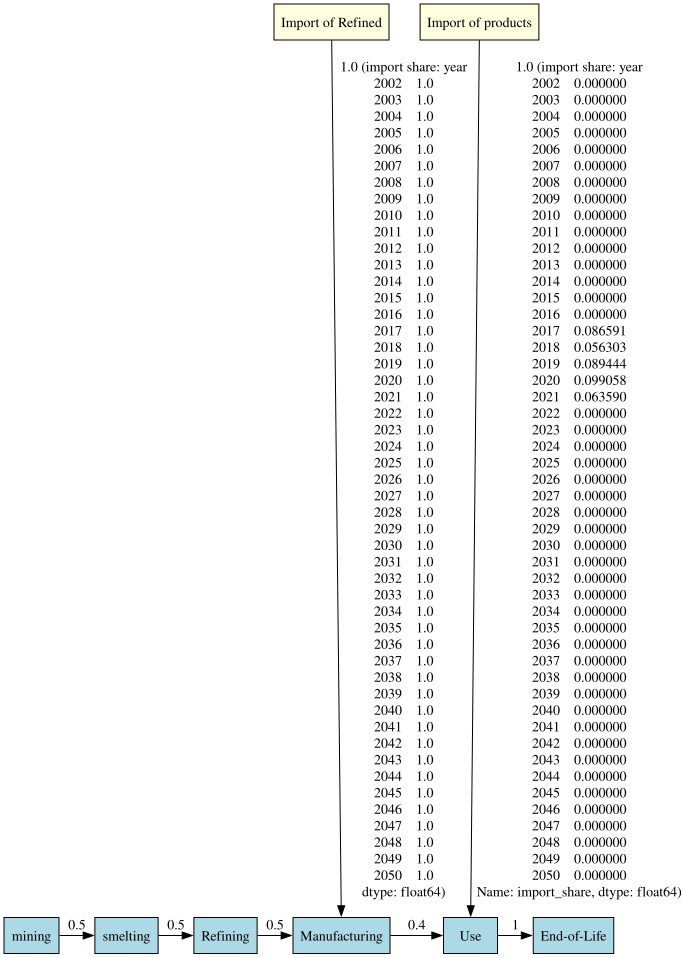

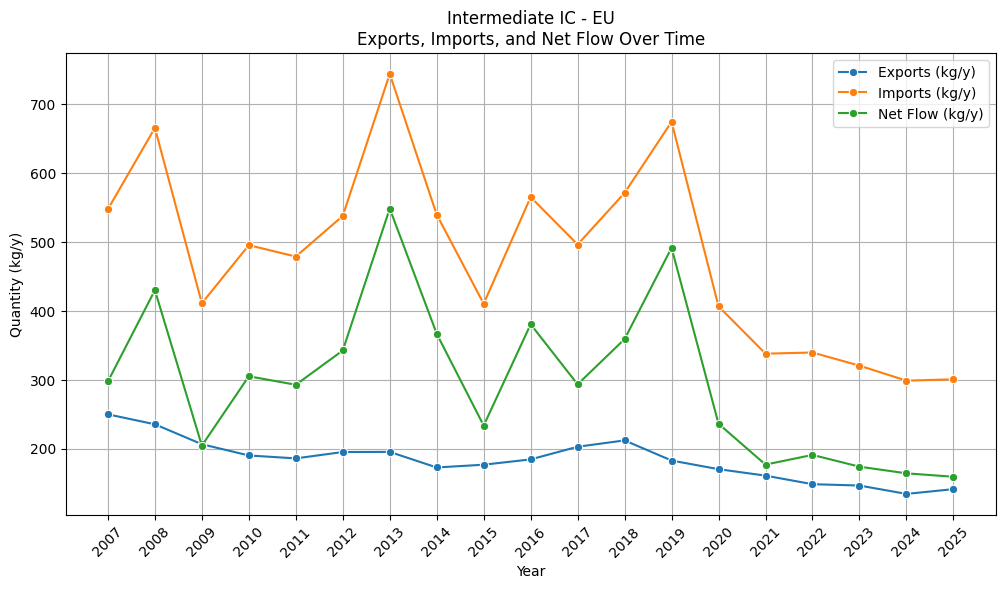

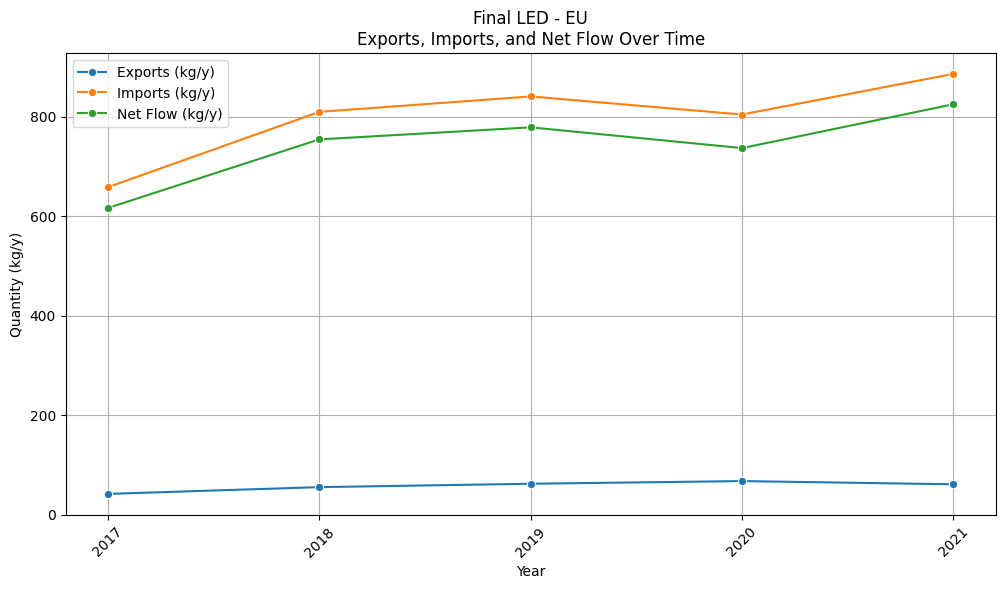

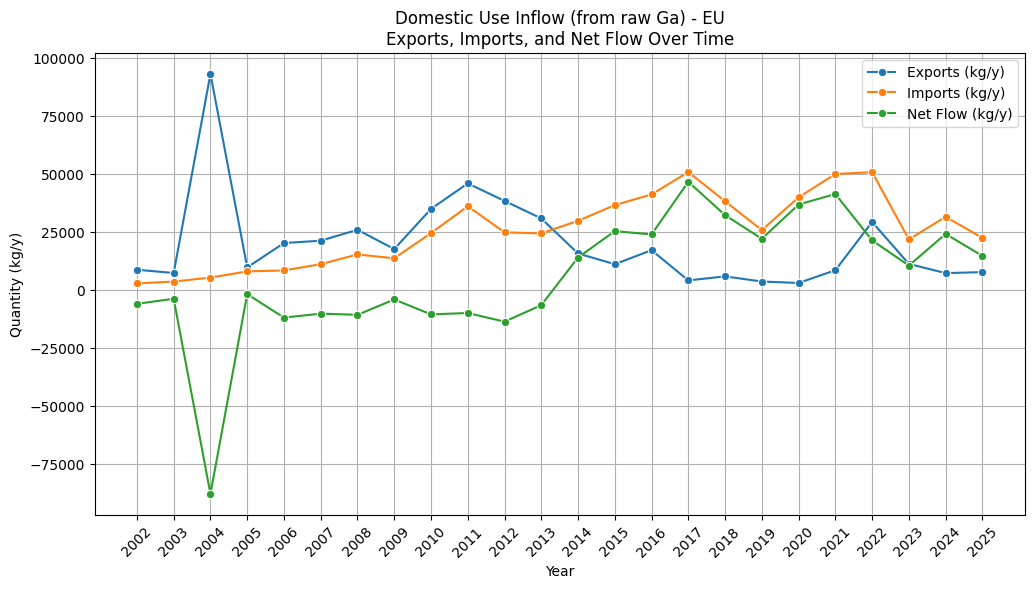

Use-phase split between products (import-derived):


,intermediate_IC,final_LED
TIME_PERIOD,,
2007,1.000,0.000
2008,1.000,0.000
2009,1.000,0.000
2010,1.000,0.000
2011,1.000,0.000
2012,1.000,0.000
2013,1.000,0.000
2014,1.000,0.000
2015,1.000,0.000


Import split (fraction of total use-phase inflow that is imported):


,intermediate_IC,final_LED
TIME_PERIOD,,
2002,0.000,0.000
2003,0.000,0.000
2004,0.000,0.000
2005,0.000,0.000
2006,0.000,0.000
2007,0.000,0.000
2008,0.000,0.000
2009,0.000,0.000
2010,0.000,0.000


,year,stage_number,stage_name,flow_type,target_stage_number,target_stage_name,value_kg,product
0,2002,1,mining,inflow,NaN,NaN,0.000000e+00,intermediate_IC
1,2003,1,mining,inflow,NaN,NaN,-0.000000e+00,intermediate_IC
2,2004,1,mining,inflow,NaN,NaN,-0.000000e+00,intermediate_IC
3,2005,1,mining,inflow,NaN,NaN,-0.000000e+00,intermediate_IC
4,2006,1,mining,inflow,NaN,NaN,-0.000000e+00,intermediate_IC
...,...,...,...,...,...,...,...,...
3033,2046,8,End-of-Life,outflow_waste,NaN,NaN,2.303708e-29,final_LED
3034,2047,8,End-of-Life,outflow_waste,NaN,NaN,5.866741e-33,final_LED
3035,2048,8,End-of-Life,outflow_waste,NaN,NaN,9.605108e-37,final_LED
3036,2049,8,End-of-Life,outflow_waste,NaN,NaN,1.010732e-40,final_LED


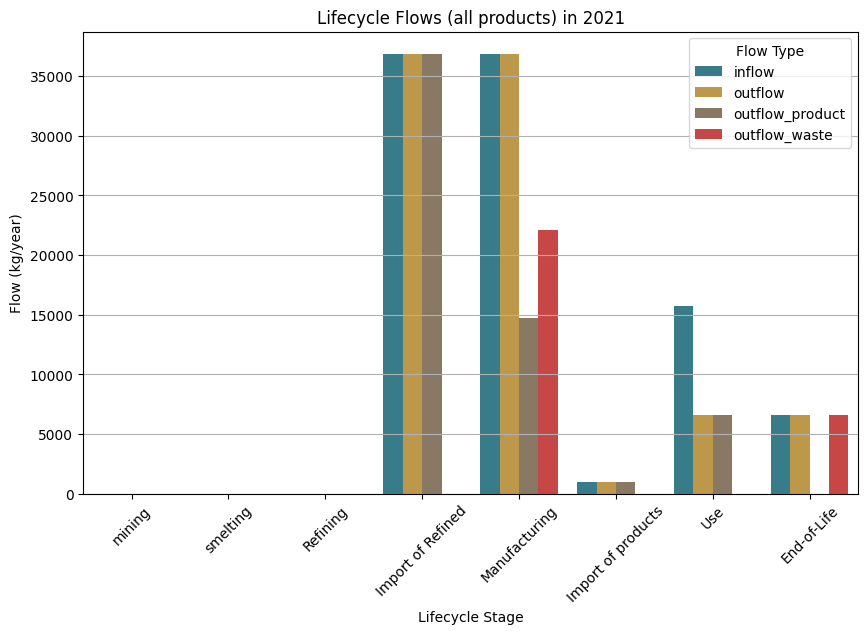

In [ ]:
add_normal_survival_curve_to_all_products(product_info)

# visualize_lifecycle_stages(lifecycle_stages_names)

##############################################################################
### Phase A ### Historical assembly
### Step 1 ### Per-product import use-phase inflows (Ga mass), historical.
import_inflows = {
    prod: translate_to_Ga_MI(
        build_imp_exp_table(eurostat_df, info["product"]),
        info["material_intensity_Ga"],
    )
    for prod, info in product_info.items()
}

plot_imp_exp_table(
    import_inflows["intermediate_IC"], display_product_name="Intermediate IC"
)
plot_imp_exp_table(import_inflows["final_LED"], display_product_name="Final LED")


### Step 2 ### Domestic use-phase inflow from raw gallium imports (single, non-product-specific).
domestic_use_inflow, raw_imp_exp = calculate_domestic_use_inflow(
    eurostat_df, raw_material_info["raw_Ga"], lifecycle_stages_names
)

plot_imp_exp_table(
    raw_imp_exp, display_product_name="Domestic Use Inflow (from raw Ga)"
)

### Step 3 ### Use-phase split between product categories, derived from import inflows.
split_df = calculate_use_phase_split(import_inflows)

### Step 4 ### Apply that split to the domestic inflow (override_split=... for scenarios).
domestic_inflows = apply_use_phase_split(domestic_use_inflow, split_df)

### Step 5 ### Combine import + domestic inflows and compute the import-split time-series.
total_inflows, import_split = combine_use_inflows(import_inflows, domestic_inflows)

# Inspect the historical assembly
print("Use-phase split between products (import-derived):")
display(split_df.round(3))
print("Import split (fraction of total use-phase inflow that is imported):")
display(pd.DataFrame(import_split).round(3))

##############################################################################
### Phase B ### Step 6: projection + dynamic MFA + lifecycle, with scenario knobs.

### Scenarios (scalar OR a per-year pd.Series) ###
# Knob 1: fraction of Manufacturing's inflow that is imported refined gallium.
#         Default 1.0 => no EU mining.
raw_import_fraction = 1.0
# Knob 2: fraction of Use's inflow that is imported finished products, per product.
#         None => use the computed import split from step 5.
#         {product: scalar_or_series} to override for scenarios.
product_import_override = None
# Knob 3: future development (BAU growth rate) of each product's use-phase inflow.
#         Scalar applied to all products, or a dict {product: growth_rate}.
product_growth = 0.0

lifecycle_frames = []
mfa_systems = {}
for prod, info in product_info.items():
    # Knob 3: project the combined historical inflow into the future (stable BAU by default)
    growth = (
        product_growth[prod] if isinstance(product_growth, dict) else product_growth
    )
    inflow_proj = add_future_BAU_projection(total_inflows[prod], growth_rate=growth)

    # Dynamic MFA
    mfa = calculate_flow_driven_MFA(
        inflow_proj,
        show_output=False,
        survival_curve_parameters=info["survival_curve_parameters"],
    )
    mfa_systems[prod] = mfa
    years = mfa.index  # historical + projected

    # Knob 1: raw-Ga import fraction -> Manufacturing (time-series aligned to MFA years)
    lifecycle_stages_names[4]["import_share"] = build_import_fraction_series(
        raw_import_fraction, years
    )
    # Knob 2: product import fraction -> Use (computed split, or scenario override),
    #         extended over the projected years by the same alignment helper.
    prod_import_fraction = (
        product_import_override[prod]
        if isinstance(product_import_override, dict)
        else import_split[prod]
    )
    lifecycle_stages_names[6]["import_share"] = build_import_fraction_series(
        prod_import_fraction, years
    )

    lf = calculate_lifecycle_flows(
        mfa, lifecycle_stages_names, use_phase_stage_number=use_phase_stage_number
    )
    lf["product"] = prod
    lifecycle_frames.append(lf)

# Per-product lifecycle flows (keeps the product split for the Sankey).
lifecycle_flows_df = pd.concat(lifecycle_frames, ignore_index=True)
display(lifecycle_flows_df)

# Plot for the year of 2021, showing the flow splits between lifecycle stages
# (aggregated across all product categories).
lifecycle_flows_agg = combine_lifecycle_flows(lifecycle_flows_df)
plot_lifecycle_flows_barplot(
    lifecycle_flows_agg[lifecycle_flows_agg["year"] == 2021],
    year=2021,
)

# Sankey: shared upstream and End-of-Life, split only at the Use stage.
plot_sankey_lifecycle_flows(
    lifecycle_flows_df,
    year=2021,
    split_stage=use_phase_stage_number,
    plot_waste_per_stage=True,
)

## Exploration

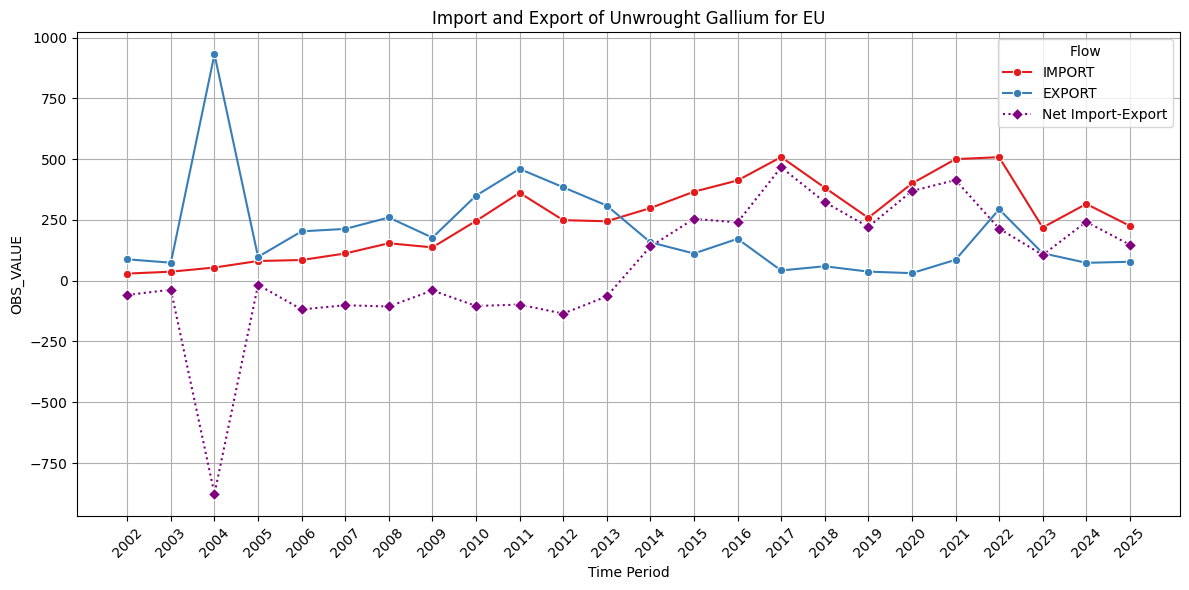

In [26]:
# Plot product "81129289" and indicators "QUANTITY_IN_100KG" with "TIME_PERIOD" on x-axis and "OBS_VALUE" on y-axis, colored by "flow"
# Plot two seperate for partner = "EXT_EU27_2020" and partner = "INT_EU27_2020" => With different legends and colors and markers
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=eurostat_df[
        (eurostat_df["product"] == 81129289)
        & (eurostat_df["indicators"] == "QUANTITY_IN_100KG")
        & (eurostat_df["partner"] == "EXT_EU27_2020")
    ],
    x="TIME_PERIOD",
    y="OBS_VALUE",
    hue="FLOW",
    marker="o",
    linestyle="-",
    palette="Set1",
)
# sns.lineplot(data=eurostat_df[(eurostat_df["product"] == 81129289) & (eurostat_df["indicators"] == "QUANTITY_IN_100KG") & (eurostat_df["partner"] == "INT_EU27_2020")],
#              x="TIME_PERIOD", y="OBS_VALUE", hue="FLOW", marker="s", linestyle="--", palette="Set2")
# Calculate and Plot the difference between FLOW = "IMPORT" and FLOW = "EXPORT" for partner = "EXT_EU27_2020"
net_import_export = eurostat_df[
    (eurostat_df["product"] == 81129289)
    & (eurostat_df["indicators"] == "QUANTITY_IN_100KG")
    & (eurostat_df["partner"] == "EXT_EU27_2020")
].pivot(index="TIME_PERIOD", columns="FLOW", values="OBS_VALUE")
net_import_export["NET_IMPORT_EXPORT"] = (
    net_import_export["IMPORT"] - net_import_export["EXPORT"]
)
sns.lineplot(
    data=net_import_export,
    x=net_import_export.index,
    y="NET_IMPORT_EXPORT",
    marker="D",
    linestyle=":",
    color="purple",
    label="Net Import-Export",
)
plt.title("Import and Export of Unwrought Gallium for EU")
plt.xlabel("Time Period")
plt.ylabel("OBS_VALUE")
plt.legend(title="Flow")
plt.xticks(rotation=45, ticks=net_import_export.index)
plt.tight_layout()
plt.grid()
plt.show()